In [14]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal


import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

from processors import temparature, season, month
from transforming import (
    Apply, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


df = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [2]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
MONTHS = [f'ct_month_{n}' for n in range(12)]
SEASONS = [f'ct_season_{n}' for n in range(4)]
ONE_HOTS = [*MONTHS, *SEASONS]


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
        Select(TEMPERATURES, mode='drop'),
    ),
    Select(TEMPERATURES, mode='drop'),
    # abs dewpoint
    # Calc('abs(dewpoint)', to='dewpoint'),
    # some simple features
    Calc('_maxtemp - _mintemp', 'tempdelta'),
    Calc('dewpoint / _temparature', 'dewpoint_rate'),
    Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('windspeed * winddirection', to='windspeed_mul_winddirection'),
    Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),
    Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='short_weather_index'),

    Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed + 0.2 * cloud', to='wide_weather_index'),

    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='weather_index'),

    # Calc('', to=''),
    Fill(0),

    # calc month one hots
    Calc(month, to='ct_month'),
    # WithSelected(['ct_month'])(
    #     pre.OneHotEncoder(),
    # ),
    # calc seasons one hots
    Calc(season, to='ct_season'),
    # WithSelected(['ct_season'])(
    #     pre.OneHotEncoder(),
    # ),

    # groupings
    # day-to-day statistic
    # WithSelected(r'(?!ct_month|ct_season).*')(
    #     Group('day', 'mean', prefix='_day_mean_', include_target=True),
    # ),
    # month-to-month statistic
    WithSelected(r'(?!day|ct_season|.*rainfall).*')(
        Group('ct_month', 'mean', prefix='_month_mean_', include_target=False),
    ),
    # # statistic by season
    WithSelected(r'(?!day|ct_month_|_month_mean_).*')(
        Group('ct_season', 'mean', prefix='season_mean_'),
    ),

    # clusterize
    # WithSelected(lambda name: name not in TEMPERATURES)(
    #     Fill('mean'),
    #     Apply(
    #         estimator=KMeans(n_clusters=3, random_state=17),
    #         locpipe=pre.StandardScaler(),
    #         to='ct_kmeans_cluster',
    #     ),
    #     Select(['kmeans_cluster'], mode='keep'),
    # ),

    # add mean for last 3 days
    WithSelected(['pressure', 'humidity', 'cloud', 'sunshine', 'windspeed'], prefix='last_3days_mean_')(
        Lag(3, 'mean'),
    ),
    # add for last day
    WithSelected(['pressure', 'humidity', 'cloud', 'sunshine', 'windspeed'], prefix='last_1days_mean_')(
        Lag(1, 'mean'),
    ),
    # drop origin columns
    Select(ORIGIN, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
)
sgd_pipe = (
    *base_pipe,
    WithSelected(r'(?!ct|day).*$')(
        KeepDataframe(pre.StandardScaler()),
    )
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,_mintemp,_maxtemp,_temparature,tempdelta,dewpoint_rate,sunshine_div_temparature,windspeed_mul_winddirection,cloud_mul_windspeed,humidity_mul_cloud,humidity_mul_sunshine,...,last_3days_mean_pressure,last_3days_mean_humidity,last_3days_mean_cloud,last_3days_mean_sunshine,last_3days_mean_windspeed,last_1days_mean_pressure,last_1days_mean_humidity,last_1days_mean_cloud,last_1days_mean_sunshine,last_1days_mean_windspeed
id,,,,,,,,,,,,,,,,,,,,,
0,-0.448184,-0.916756,-0.640635,-1.924540,0.863637,-0.629679,-0.598201,-0.184904,0.750543,-0.715426,...,0.729726,0.943633,0.976402,-0.992956,-0.678037,0.671342,0.636608,0.681269,-0.729417,-0.464591
1,-1.258430,-1.678817,-1.482526,-2.057039,0.944336,-0.975223,-0.564008,0.335084,1.295607,-1.064447,...,0.729726,0.943633,0.976402,-0.992956,-0.678037,0.671342,0.636608,0.681269,-0.729417,-0.464591
2,-1.495575,-1.235758,-1.501660,0.394201,-2.449100,2.360809,-0.470658,-0.904078,-1.526162,1.205831,...,0.864253,1.450483,1.055925,-1.130648,-0.446508,1.042718,1.662490,0.847728,-1.032826,0.011068
3,-1.041047,-1.466149,-1.176384,-1.990789,0.882495,-0.975223,0.000976,1.842105,1.505035,-1.064447,...,1.293457,0.690208,-0.030889,-0.229390,-0.402172,1.856207,-0.902213,-1.593680,1.256535,-0.373507
4,-1.377003,-0.899033,-1.061581,1.255448,-2.957697,0.290862,-0.619910,-0.616257,-2.179248,-0.381723,...,1.037215,1.197058,0.154664,-0.367082,0.504241,-0.036039,1.662490,1.069675,-1.032826,1.397562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,-0.606281,-0.562308,-0.640635,-0.069547,1.084468,-0.943810,-0.678525,0.282900,1.235534,-1.029071,...,0.928313,-0.576919,0.870371,-0.942886,1.361392,0.388390,-0.517508,0.681269,-1.032826,0.891542
2186,-1.159620,-1.607927,-1.291187,-2.123289,0.388594,-0.975223,-0.200378,1.543109,0.944539,-1.064447,...,0.415830,0.500139,0.870371,-1.093095,1.248091,0.176175,1.918960,0.681269,-1.005244,0.031309
2187,-1.554862,-1.306647,-1.463392,0.327951,-0.671611,1.009777,-0.444065,0.992744,-0.029302,0.376131,...,0.127559,1.260415,0.976402,-1.393515,1.115084,-0.212885,1.149549,0.681269,-1.032826,1.367201


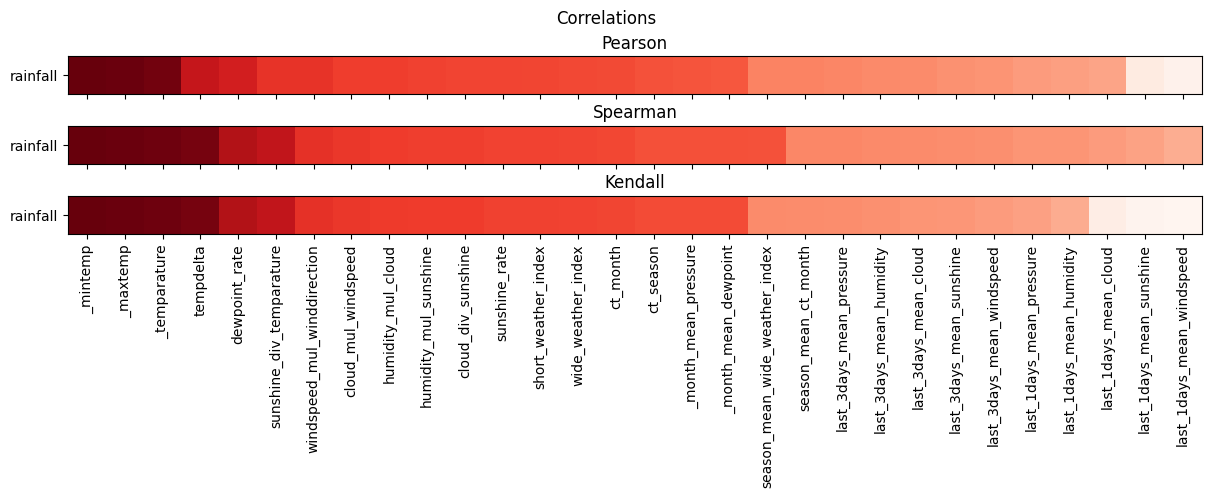

In [405]:
THRESHOLD = 0.075

data: pd.DataFrame = X.copy()   # type: ignore
labels = data.columns
data['rainfall'] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 5), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    rainfall_corr = data.corr(method)[['rainfall']].drop('rainfall').sort_values('rainfall', ascending=False)
    values = rainfall_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Reds')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=['rainfall'])
plt.show()

__modeling__

In [3]:
estimator = SGDClassifier(
    loss='log_loss',
    # learning_rate='adaptive',
    # eta0=0.001,
    alpha=0.001,
    penalty='l1',
    max_iter=15000,
    n_jobs=-1,
    # early_stopping=True,
    class_weight=CLASS_WEIGHTS.to_dict(),
    shuffle=False,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
sgd = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.89664; TRAIN f1=0.89781 | VALID ROC AUC=0.89473; VALID f1=0.89060
Fold: 1; TRAIN ROC AUC=0.89701; TRAIN f1=0.89243 | VALID ROC AUC=0.89005; VALID f1=0.89320
Fold: 2; TRAIN ROC AUC=0.89960; TRAIN f1=0.89101 | VALID ROC AUC=0.87998; VALID f1=0.89101
Fold: 3; TRAIN ROC AUC=0.89588; TRAIN f1=0.89030 | VALID ROC AUC=0.90177; VALID f1=0.88973
Fold: 4; TRAIN ROC AUC=0.89193; TRAIN f1=0.89002 | VALID ROC AUC=0.92219; VALID f1=0.89231
Fold: 5; TRAIN ROC AUC=0.89931; TRAIN f1=0.89294 | VALID ROC AUC=0.88282; VALID f1=0.89788
Fold: 6; TRAIN ROC AUC=0.89831; TRAIN f1=0.89329 | VALID ROC AUC=0.87306; VALID f1=0.88180
MEAN: TRAIN ROC AUC=0.89695; TRAIN f1=0.89254 | VALID ROC AUC=0.89208; VALID f1=0.89093


In [4]:
estimator = LogisticRegression(
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.90101; TRAIN f1=0.90523 | VALID ROC AUC=0.89121; VALID f1=0.90411
Fold: 1; TRAIN ROC AUC=0.90031; TRAIN f1=0.90571 | VALID ROC AUC=0.89616; VALID f1=0.90800
Fold: 2; TRAIN ROC AUC=0.90308; TRAIN f1=0.90672 | VALID ROC AUC=0.87217; VALID f1=0.90297
Fold: 3; TRAIN ROC AUC=0.89914; TRAIN f1=0.90713 | VALID ROC AUC=0.89952; VALID f1=0.90625
Fold: 4; TRAIN ROC AUC=0.89510; TRAIN f1=0.90582 | VALID ROC AUC=0.92654; VALID f1=0.90448
Fold: 5; TRAIN ROC AUC=0.90185; TRAIN f1=0.90512 | VALID ROC AUC=0.87872; VALID f1=0.91304
Fold: 6; TRAIN ROC AUC=0.90274; TRAIN f1=0.90760 | VALID ROC AUC=0.87787; VALID f1=0.89231
MEAN: TRAIN ROC AUC=0.90046; TRAIN f1=0.90619 | VALID ROC AUC=0.89174; VALID f1=0.90445


In [56]:
estimator = KNeighborsClassifier(
    weights='uniform',
    algorithm='auto',
    n_neighbors=11,
    p=1,
    # leaf_size=60,
    n_jobs=-1,
)
_ = checkup(estimator, SGD_X, y)
knn = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.92280; TRAIN f1=0.91868 | VALID ROC AUC=0.87756; VALID f1=0.91207
Fold: 1; TRAIN ROC AUC=0.92416; TRAIN f1=0.91624 | VALID ROC AUC=0.87783; VALID f1=0.90909
Fold: 2; TRAIN ROC AUC=0.92408; TRAIN f1=0.91772 | VALID ROC AUC=0.85219; VALID f1=0.90389
Fold: 3; TRAIN ROC AUC=0.92431; TRAIN f1=0.91678 | VALID ROC AUC=0.88460; VALID f1=0.91650
Fold: 4; TRAIN ROC AUC=0.92433; TRAIN f1=0.91792 | VALID ROC AUC=0.88152; VALID f1=0.90467
Fold: 5; TRAIN ROC AUC=0.92733; TRAIN f1=0.91883 | VALID ROC AUC=0.86787; VALID f1=0.90309
Fold: 6; TRAIN ROC AUC=0.92725; TRAIN f1=0.91862 | VALID ROC AUC=0.86482; VALID f1=0.89879
MEAN: TRAIN ROC AUC=0.92490; TRAIN f1=0.91783 | VALID ROC AUC=0.87234; VALID f1=0.90687


Fold: 0; TRAIN ROC AUC=0.90908; TRAIN f1=0.88938 | VALID ROC AUC=0.87937; VALID f1=0.88596
Fold: 1; TRAIN ROC AUC=0.90580; TRAIN f1=0.89093 | VALID ROC AUC=0.90287; VALID f1=0.88341
Fold: 2; TRAIN ROC AUC=0.90750; TRAIN f1=0.89597 | VALID ROC AUC=0.87982; VALID f1=0.87361
Fold: 3; TRAIN ROC AUC=0.90448; TRAIN f1=0.89166 | VALID ROC AUC=0.90249; VALID f1=0.88889
Fold: 4; TRAIN ROC AUC=0.90107; TRAIN f1=0.89635 | VALID ROC AUC=0.92367; VALID f1=0.90281
Fold: 5; TRAIN ROC AUC=0.90626; TRAIN f1=0.89435 | VALID ROC AUC=0.88156; VALID f1=0.87444
Fold: 6; TRAIN ROC AUC=0.90841; TRAIN f1=0.89101 | VALID ROC AUC=0.87057; VALID f1=0.89655
MEAN: TRAIN ROC AUC=0.90608; TRAIN f1=0.89281 | VALID ROC AUC=0.89148; VALID f1=0.88653


100%|██████████| 20/20 [00:51<00:00,  2.57s/it]


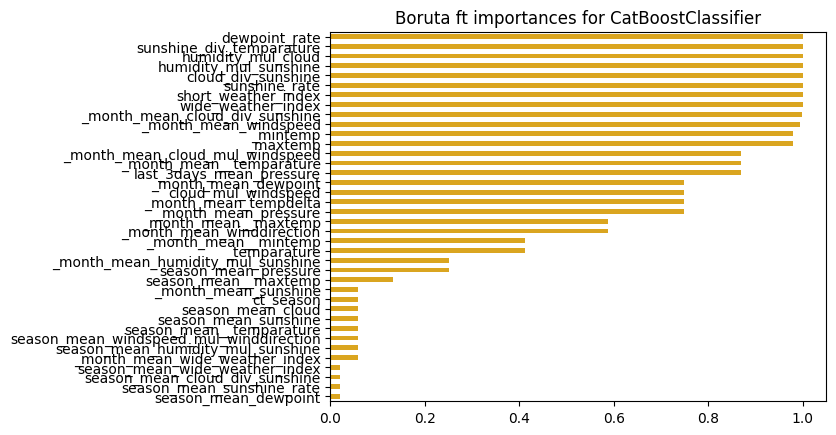

In [61]:
estimator = CatBoostClassifier(
    n_estimators=1500,
    # iterations=1500,
    learning_rate=0.001,
    depth=3,
    class_weights=CLASS_WEIGHTS,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.99)
catboost = model = estimator.fit(X, y)

__submission__

In [ ]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

In [6]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

a5fd0107d52a4b259465d5c0658d2e43


In [40]:
# KNeighbours
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = knn.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c12ece55df844d2b97cfad1e9ca388f0


In [62]:
# CatBoost
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b5c1648db89343d191cbd8f500ebbc87


__NN approach__

In [63]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [64]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )
        # return (
        #     torch.as_tensor(self.x[index], dtype=torch.float32),
        #     torch.as_tensor(self.y[index], dtype=torch.float32)
        # )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 69])

In [65]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # linears
            torch.nn.Flatten(1),
            torch.nn.Linear(CHANNELS * ((features - days + 1) // 2), linear_channels // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels // 2, linear_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(linear_channels // 4, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

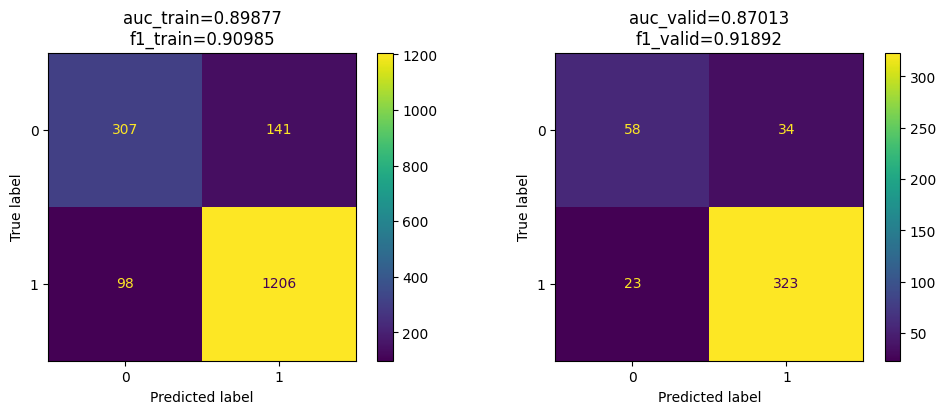

In [66]:
torch.manual_seed(11)
DAYS = 3
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=8,
    linear_channels=32,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=25, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [67]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.91041; TRAIN f1=0.91836 | VALID ROC AUC=0.87984; VALID f1=0.90909
Fold: 1; TRAIN ROC AUC=0.90807; TRAIN f1=0.91652 | VALID ROC AUC=0.89462; VALID f1=0.91720
Fold: 2; TRAIN ROC AUC=0.91296; TRAIN f1=0.91618 | VALID ROC AUC=0.86705; VALID f1=0.90644
Fold: 3; TRAIN ROC AUC=0.90684; TRAIN f1=0.91325 | VALID ROC AUC=0.88840; VALID f1=0.90417
Fold: 4; TRAIN ROC AUC=0.90164; TRAIN f1=0.92313 | VALID ROC AUC=0.90584; VALID f1=0.91097
Fold: 5; TRAIN ROC AUC=0.91225; TRAIN f1=0.91788 | VALID ROC AUC=0.86181; VALID f1=0.90756
Fold: 6; TRAIN ROC AUC=0.91240; TRAIN f1=0.91655 | VALID ROC AUC=0.88428; VALID f1=0.91992
MEAN: TRAIN ROC AUC=0.90922; TRAIN f1=0.91741 | VALID ROC AUC=0.88312; VALID f1=0.91076


__final fit__

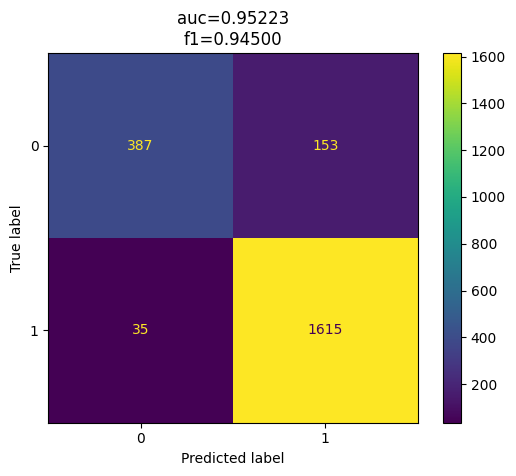

In [68]:
torch.manual_seed(11)
DAYS = 3
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=8,
    linear_channels=32,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [69]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = cnn.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

404b94b10eaf4294832a8f895ef55d20


__mix predictions__

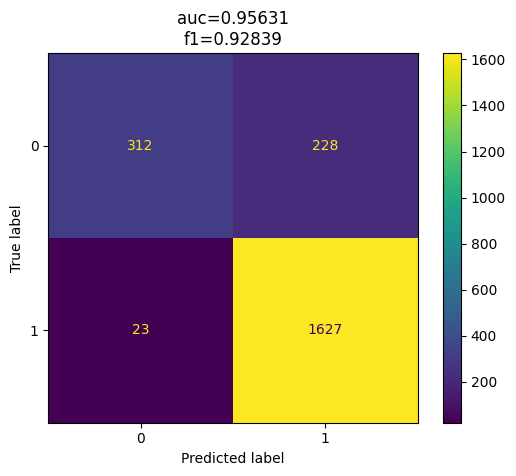

In [54]:
weights = np.array([0.4, 0.4, 0.2]).reshape(3, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0]
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [56]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

fea2f6cbe778477db386bf9ca82a30f7


In [ ]:
#